In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd

In [15]:
import sys 
sys.path.append('../')
from ft_engineering import preprocesar_datos

def build_model(model, X_train, y_train):
    """Entrena  el modelo y retorna la instancia ajustada"""
    print(f"Entrenando {model.__class__.__name__}...")
    model.fit(X_train, y_train)
    print('Entrenamiento finalizado')
    return model

def summarize_classification(y_test, y_pred):
    """Genera la tabla resumen y el gráfico de matriz de confusión"""
    print('***Tabla Resumen de Evaluación***')
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de confusión')
    plt.ylabel('Valor real  (y_test)')
    plt.xlabel('Predicción (y_pred)')
    plt.show()

In [16]:
df = pd.read_excel('../data/Base_de_datos.xlsx')

#Limpieza igual que en el EDA

columnas_a_borrar = [
    'tipo_credito', 'huella_consulta', 'saldo_mora_codeudor', 
    'puntaje_datacredito', 'tendencia_ingresos', 'saldo_mora', 
    'saldo_total', 'saldo_principal', 'puntaje'
]

df = df.drop(columns=columnas_a_borrar, errors='ignore')


#Separar Feactures (X) y Target (y)
X= df.drop(columns=['Pago_atiempo'])
y= df['Pago_atiempo']

#Identificar columnas por tipo para transformar
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = ['tipo_laboral']
ord_cols = []

#Aplicamos el pipeline desde el script ft_engineering.py
X_transformado, preprocessor = preprocesar_datos(X, num_cols, cat_cols, ord_cols)


#Dividir en conjuntos de Entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test =train_test_split(X_transformado, y, test_size=0.2, random_state=42)


Peso asignado a la clase minoritaria: 20.15
Entrenando XGBClassifier...
Entrenamiento finalizado
***Tabla Resumen de Evaluación***
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       104
           1       0.95      1.00      0.97      2049

    accuracy                           0.95      2153
   macro avg       0.48      0.50      0.49      2153
weighted avg       0.91      0.95      0.93      2153



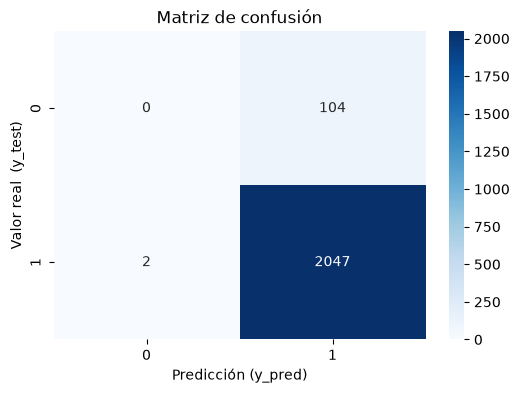

In [17]:
#Balancear el modelo
ratio_desbalance = len(y_train[y_train == 1]) / len(y_train[y_train == 0])
print(f"Peso asignado a la clase minoritaria: {ratio_desbalance:.2f}")


#Instanciar el modelo (XGBoost es excelente para el desbalance de clases)

modelo_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio_desbalance)

#1 Entrenar usando la función
modelo_entrenado = build_model(modelo_xgb, X_train, y_train)

#2 Generar predicciones
y_pred = modelo_entrenado.predict(X_test)

#3 Evaluar usando la función
summarize_classification(y_test, y_pred)

In [18]:
#Probaremos otros modelos para medir su desempeño y elegir el mejor

modelos = {
    'XGBoost' : xgb.XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=ratio_desbalance),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Regresión Logística': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
}

metricas = []

In [19]:
for nombre, modelo in modelos.items():
    print(f'Evaluando {nombre}')

    modelo_entrenado = build_model(modelo, X_train, y_train)
    y_pred= modelo_entrenado.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    metricas.append({'Modelo': nombre, 'F1-Score': f1, 'Accuracy': acc})

df_metricas = pd.DataFrame(metricas)
display(df_metricas)

Evaluando XGBoost
Entrenando XGBClassifier...
Entrenamiento finalizado
Evaluando Random Forest
Entrenando RandomForestClassifier...
Entrenamiento finalizado
Evaluando Regresión Logística
Entrenando LogisticRegression...
Entrenamiento finalizado


,Modelo,F1-Score,Accuracy
0,XGBoost,0.974762,0.950766
1,Random Forest,0.972070,0.945657
2,Regresión Logística,0.722087,0.574547


C:\Users\Cristian\AppData\Local\Temp\ipykernel_17908\3492222098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_metricas, x='Modelo', y='F1-Score', palette='Set2')


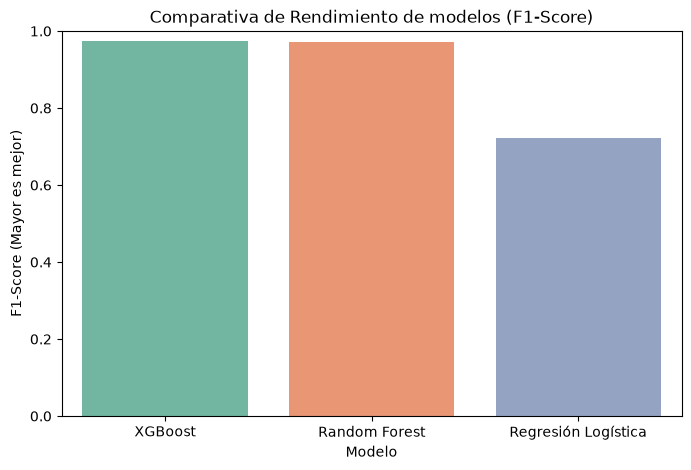

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_metricas, x='Modelo', y='F1-Score', palette='Set2')
plt.title('Comparativa de Rendimiento de modelos (F1-Score)')
plt.ylabel('F1-Score (Mayor es mejor)')
plt.ylim(0,1)
plt.show()

Al entrenar los modelos nos dimos cuenta que F1-Score, es perfecto, por lo cual, tenemos una caso de Data Leakage, a continuación vamos a ver cual es la feacture que está provocando esto y la vamos a eliminar del dataset

C:\Users\Cristian\AppData\Local\Temp\ipykernel_17908\3657901307.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importancias.head(10), x='Importancia', y='Variable', palette='viridis')


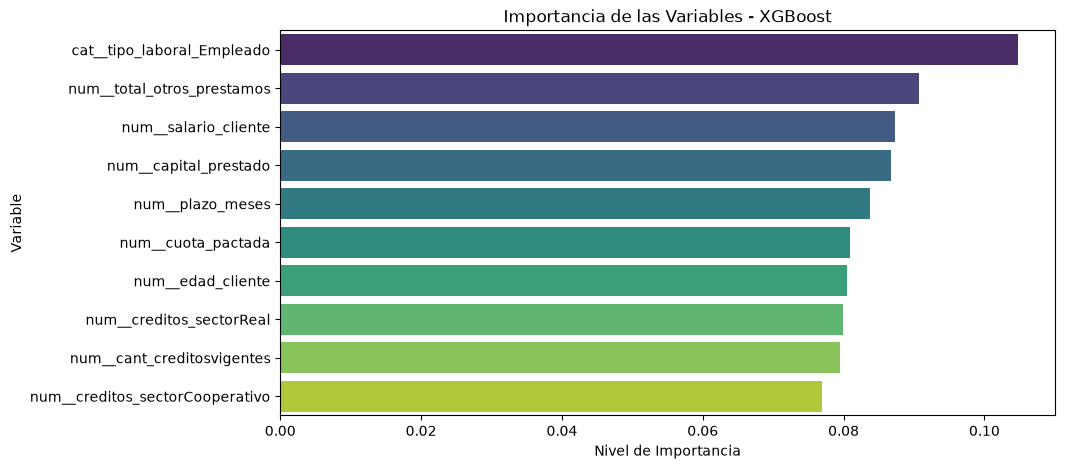

In [21]:
# Extraer importancias del modelo XGBoost
importancias = modelos['XGBoost'].feature_importances_

# Extraemos los nombres desde el preprocesador, no desde X_train
nombres_columnas = preprocessor.get_feature_names_out()

# Organizar los datos de mayor a menor importancia
df_importancias = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Graficar el Top 10
plt.figure(figsize=(10, 5))
sns.barplot(data=df_importancias.head(10), x='Importancia', y='Variable', palette='viridis')
plt.title('Importancia de las Variables - XGBoost')
plt.xlabel('Nivel de Importancia')
plt.show()

La feacture "Puntaje" estaba provocando Data Leakage, al eliminarla, vemos como el gráfico de las variables se encuentra bien equilibrado

Como conclusión vemos como el modelo de XGBoost fue el que logró mayor predicción que los demás, con un F1-Score de 0.97. En un caso real, y con datos reales, es poco probable que nos dé una valor tan alto de predicción, de hecho sería un caso para revisar, pero en este entorno de aprendizaje, puede suceder.